In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo
from scipy.optimize import differential_evolution

from src.fire_spreading_model import FireSpreadingAdvanced, Parameters
from src.data_preprocessing import SentinelClient
from src.helper_functions import calculate_rect_dimensions, collect_weather_data
from test.optimization import objective_function

/Users/hanno/PycharmProjects/Adv_Modelling_and_Simulation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Gathering Test Data
https://www.fire.ca.gov/incidents/2025/7/1/green-fire/

Width: 14.322km, Height: 21.151km, Area: 302.931sq km


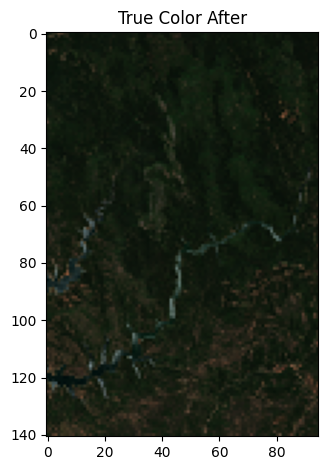

In [2]:
start_date = ("2025-06-20", "2025-06-25")  # actual start date: 2025-07-01 4:19 pm
end_date = ("2025-07-18", "2025-07-20")  # actual end date: containment started with 2025-7-19

lat_range = (40.720, 40.910)
lon_range = (-122.009, -122.179)

width_km, height_km = calculate_rect_dimensions(lat_range, lon_range)
px_dimemnsion_km = 0.150
width_px = round(width_km / px_dimemnsion_km)
height_px = round(height_km / px_dimemnsion_km)

# origin of the fire
start_coord = (40.834939, -122.094146)
start_px = (round((start_coord[0] - lat_range[0]) / (lat_range[1] - lat_range[0]) * height_px),
            round((start_coord[1] - lon_range[0]) / (lon_range[1] - lon_range[0]) * width_px))

sc = SentinelClient()
photo_true_colour_before, _ = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                           np.max(lon_range), np.max(lat_range),
                                           start_date[0], start_date[1], width_px, height_px)

photo_true_colour_after, time_end = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                          np.max(lon_range), np.max(lat_range),
                                          end_date[0], end_date[1], width_px, height_px)

print(f"Width: {width_km:.3f}km, Height: {height_km:.3f}km, Area: {width_km*height_km:.3f}sq km")

plt.imshow(photo_true_colour_before)
plt.title("True Color Before")
plt.tight_layout()
plt.show()

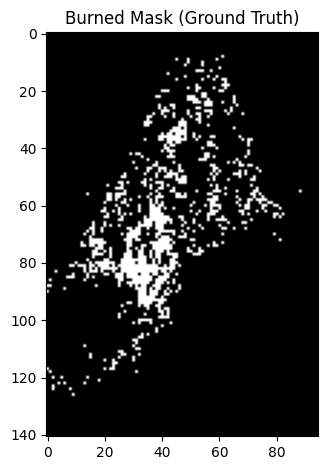

In [7]:
plt.imshow(burned_mask, cmap='gray')
plt.title("Burned Mask (Ground Truth)")
plt.tight_layout()
plt.show()

In [3]:
 # set manual start time
time_start = datetime.fromisoformat("2025-07-01T16:00")
time_start = time_start.replace(tzinfo=ZoneInfo("America/Los_Angeles"))
time_start = time_start.astimezone(timezone.utc)

# use the end time from image and round it to nearest hour
time_end = datetime.fromisoformat(time_end)
time_end = (time_end + timedelta(minutes=30)).replace(minute=0, second=0, microsecond=0)

# calculate passed hours
delta_t = int((time_end - time_start).total_seconds() // 3600)
# Retrieve data
data_before = sc.get_data(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                          start_date[0], start_date[1], width_px, height_px)
data_after = sc.get_data(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                         end_date[0], end_date[1], width_px, height_px)

fuel_before, water_before, moisture_before, burnt_before = data_before
fuel_after_real_data, water_after_real_data, moisture_after_real_data, burnt_after_real_data = data_after

topo = sc.get_topo(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                   width_px, height_px)

#dNBR = (NBR_before - NBR_after)
dnbr = (burnt_before - burnt_after_real_data)

# Create the Target Burn Mask based on NBR and water levels
# white pixels indicate areas that were burned, while black pixels indicate unburned areas
target_mask = (dnbr > 0.1)

# severity mask based on dNBR
severity_color_mask, burned_mask = sc.get_severity_mask(dnbr)

weather_data = collect_weather_data(np.average(lat_range), np.average(lon_range), time_start, time_end)
wind_speed = weather_data["Wind Speed (kph)"].to_list()
wind_direction = weather_data["Wind Direction (°)"].to_list()
weather_data

,Time,Wind Speed (kph),Wind Direction (°)
23,2025-07-01 23:00:00+00:00,8.7,201
24,2025-07-02 00:00:00+00:00,6.5,226
25,2025-07-02 01:00:00+00:00,7.5,60
26,2025-07-02 02:00:00+00:00,15.3,16
27,2025-07-02 03:00:00+00:00,13.9,13
...,...,...,...
470,2025-07-20 14:00:00+00:00,0.8,63
471,2025-07-20 15:00:00+00:00,1.2,231
472,2025-07-20 16:00:00+00:00,2.8,252
473,2025-07-20 17:00:00+00:00,6.3,235


# Model

In [6]:
start_px = (round(height_px - ((start_coord[0] - lat_range[0]) / (lat_range[1] - lat_range[0]) * height_px)),
            round((start_coord[1] - lon_range[0]) / (lon_range[1] - lon_range[0]) * width_px))

params_dict = {
    "n": height_px, "m": width_px, "mu_H": 0.85, "dF": 0.26, "dW": 0.51, "ignition_temp": 0.26, "ignition_fuel": 0.09, "extinction_fuel": 0.09, "wind": None, "wind_velocity": wind_speed, "wind_direction": wind_direction, "start_cells": [start_px], "random_F": False, "fuel_mask": fuel_before, "water_mask": water_before, "moisture_mask": moisture_before, "topo_mask": topo, "k_slope": 10.04, "resolution": px_dimemnsion_km * 1000, "wind_strength_factor": 4.36, "timesteps": delta_t,
}

with open("../presentation_images/sr_opt_de-seed=1234_px=150m.json", "r") as f:
    params_opt = json.load(f)

params = {**params_dict, **params_opt}
parameter = Parameters(**params)

print(parameter.dF)  # test
sim = FireSpreadingAdvanced(parameter, precompute_mu=True)
sim.run_simulation(timesteps=delta_t, visualization=True,
                   gif_name=f"../presentation_images/gf_px={round(px_dimemnsion_km*1000)}m")

0.6631526167938725


In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(sim.calculate_simulation_burned_mask(), cmap='gray')
plt.title("Simulated Burned Mask")
plt.subplot(1,2,2)
plt.imshow(burned_mask, cmap='gray')
plt.title('"Real" Burned Mask')
plt.show()